In [26]:
import numpy as np

class EulerPhysics:
    def __init__(self, gamma=1.4):
        self.gamma = gamma

    def U_to_primitive(self, U):
        rho = U[0]
        u   = U[1]/rho
        E   = U[2]/rho
        p   = (self.gamma-1)*(rho*E - 0.5*rho*u**2)
        a   = np.sqrt(self.gamma*p/rho)
        return rho, u, E, p, a

    def lp(self, u, a):
        # λ1 = u, λ2 = u + a, λ3 = u - a
        return [max(u, 0.0), max(u + a, 0.0), max(u - a, 0.0)]

    def lm(self, u, a):
        # λ1 = u, λ2 = u + a, λ3 = u - a
        return [min(u, 0.0), min(u + a, 0.0), min(u - a, 0.0)]

    def build_F(self, rho, u, a, L):
        gamma = self.gamma
        l1, l2, l3 = L

        F1 = 2*(gamma-1)*l1 + l2 + l3
        F2 = 2*(gamma-1)*l1*u + l2*(u+a) + l3*(u-a)
        F3 = ((gamma-1)*l1*u**2
              + 0.5*l2*(u+a)**2
              + 0.5*l3*(u-a)**2
              + (3-gamma)/(2*(gamma-1))*(l2+l3)*a**2)

        return (rho/(2*gamma)) * np.array([F1, F2, F3])

class Solver:
    def __init__(self, phys, scheme, xmin, xmax, N, wl, wr, CFL=0.4):
        
        self.phys = phys
        self.flux = scheme
        self.CFL = CFL

        self._build_grid(xmin, xmax, N)
        self._build_IC(wl, wr)
        
        self.U_new = np.zeros_like(self.U)
        self.F = np.zeros((self.N-1,3))

    def _build_grid(self, xmin, xmax, N):
        self.N = N
        self.x = np.linspace(xmin, xmax, N)
        self.dx = (xmax - xmin) / (N-1)

    def _build_IC(self, wl, wr):
        self.U = np.zeros((self.N,3))

        for i in range(self.N):
            w = wl if self.x[i] < 0 else wr 
            rho, u, p = (w[var] for var in ('rho', 'u', 'p'))

            E = p/((self.phys.gamma-1)*rho) + 0.5*u**2
            self.U[i] = [rho, rho*u, rho*E]
    def _calc_flux(self):
        F = np.zeros((self.N-1, 3))
        for i in range(self.N-1):
            for offset in [0,1]:
                rho, u, _, _, a = self.phys.U_to_primitive(self.U[i+offset])
                if offset == 0: # left state
                    Fp = self.phys.build_F(rho, u, a, self.phys.lp(u, a))
                else: # right state
                    Fm = self.phys.build_F(rho, u, a, self.phys.lm(u, a))
            if self.flux == "sw":
                F[i] = Fp + Fm
            else:
                raise ValueError("Unknown flux scheme")
        return F

    def _calc_u(self):
        U_new = self.U.copy()

        for i in range(1, self.N-1):
            U_new[i] = self.U[i] - (self.dt/self.dx)*(self.F[i] - self.F[i-1])

        # transmissive BC
        U_new[0]  = U_new[1]
        U_new[-1] = U_new[-2]

        return U_new

    def _calc_dt(self):
        max_speed = 0.0

        for i in range(self.N):
            _, u, _, _, a = self.phys.U_to_primitive(self.U[i])
            max_speed = max(max_speed, abs(u) + a)

        return self.CFL * self.dx / max_speed
    def run(self, t_start, t_end):
        t = t_start
        step = 0

        while t < t_end:
            self.dt = self._calc_dt()
            self.F = self._calc_flux()
            self.U = self._calc_u()

            t += self.dt
            step += 1


In [27]:
WL = {"rho":1.0,   "u":0.0, "p":100000.0}
WR = {"rho":0.125, "u":0.0, "p":10000.0}

phys = EulerPhysics(gamma=1.4)

solver = Solver(
    phys=phys,
    scheme="sw",
    xmin=-10,
    xmax=10,
    N=50,
    wl=WL,
    wr=WR,
    CFL=0.4
)

solver.run(0.0, 0.01)

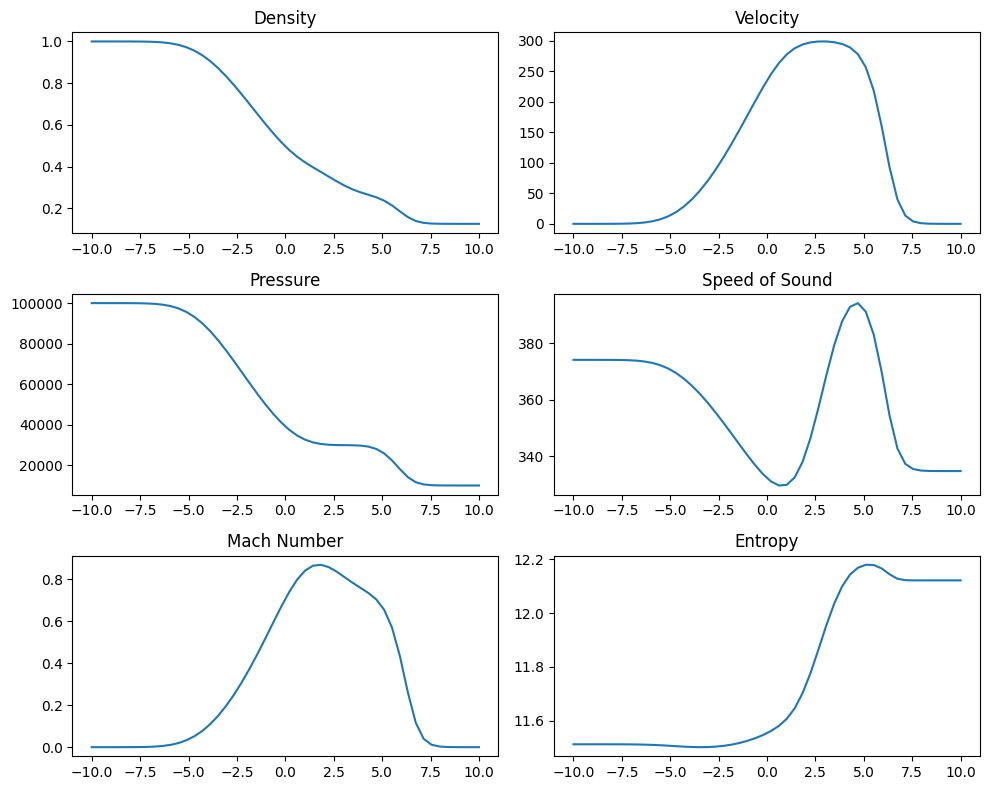

In [28]:
import matplotlib.pyplot as plt
import numpy as np

def plot_solution(solver):
    N  = solver.N
    x  = solver.x
    U  = solver.U
    phys = solver.phys

    rho = np.zeros(N)
    u   = np.zeros(N)
    p   = np.zeros(N)
    a   = np.zeros(N)
    M   = np.zeros(N)
    s   = np.zeros(N)

    for i in range(N):
        rho[i], u[i], E, p[i], a[i] = phys.U_to_primitive(U[i])
        M[i] = u[i] / a[i]
        s[i] = np.log(p[i] / rho[i]**phys.gamma)

    plt.figure(figsize=(10,8))

    plt.subplot(3,2,1)
    plt.plot(x, rho)
    plt.title("Density")

    plt.subplot(3,2,2)
    plt.plot(x, u)
    plt.title("Velocity")

    plt.subplot(3,2,3)
    plt.plot(x, p)
    plt.title("Pressure")

    plt.subplot(3,2,4)
    plt.plot(x, a)
    plt.title("Speed of Sound")

    plt.subplot(3,2,5)
    plt.plot(x, M)
    plt.title("Mach Number")

    plt.subplot(3,2,6)
    plt.plot(x, s)
    plt.title("Entropy")

    plt.tight_layout()
    plt.show()
phys = EulerPhysics(gamma=1.4)

wl = {"rho":1.0,   "u":0.0, "p":100000.0}
wr = {"rho":0.125, "u":0.0, "p":10000.0}

solver = Solver(phys, scheme="sw",
                xmin=-10, xmax=10, N=50,
                wl=wl, wr=wr)

solver.run(0.0, 0.01)

plot_solution(solver)
